<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Hands_on_Activity_2_2_Classification_De_los_Reyes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 312
Code Title: | Predictive Analytics using Machine Learning
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**ACTIVITY NO.** | **TITLE**
**Name** | De los Reyes, Jann Moises Nyll B.
**Section** | CPE31S3
**Date Performed**: | September 13, 2024
**Date Submitted**: | September 12, 2024
**Instructor**: | Dr. Alonica Villanueva / Engr. Roman M. Richard

<hr>

## 1. Objectives

This activity aims to strengthen understanding of classification and ability to demonstrate binary, multiclass, multilabel, and multioutput classification while evaluating model performance.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate classification for binary, multiclass, multilabel and multioutput problems.
* Evaluate the performance of different classification models through an analysis of different performance metrics.

## 3. Procedures and Outputs

In the first module, we mentioned that the most common supervised learning tasks are regression (predicting values) and classification (predicting classes). Then, we explored a regression tasks. Now we will turn our attention to classification systems.

### 3.1 MNIST

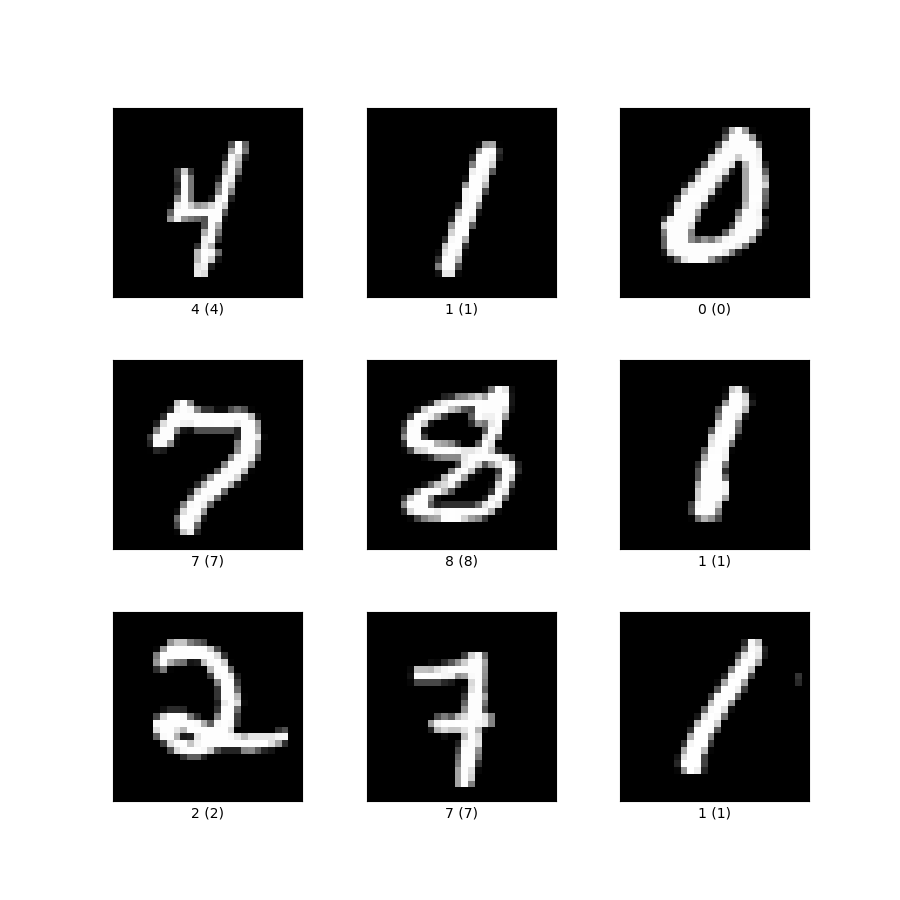

In this chapter, we will be using the MNIST dataset, which is a set of 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau. Each image is labeled with the digit it represents. This set has been studied so much that it is often called the “Hello World” of Machine Learning: whenever people come up with a new classification algorithm, they are curious to see how it will perform on MNIST. Whenever someone learns Machine Learning, sooner or later they tackle MNIST.

Scikit-Learn provides many helper functions to download popular datasets. MNIST is one of them. The following code fetches the MNIST dataset:

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

Datasets loaded by Scikit-Learn generally have a similar dictionary structure including:
* A DESCR key describing the dataset
* A data key containing an array with one row per instance and one column per feature
* A target key containing an array with the labels

In [ ]:
# extra code – it's a bit too long
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [ ]:
mnist.keys()  # extra code – we only use data and target in this notebook

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

There are 70,000 images, and each image has 784 features. This is because each image is 28×28 pixels, and each feature simply represents one pixel’s intensity, from 0
(white) to 255 (black). Let’s take a peek at one digit from the dataset. All you need to do is grab an instance’s feature vector, reshape it to a 28×28 array, and display it using Matplotlib’s imshow() function:

In [ ]:
X, y = mnist.data, mnist.target
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X.shape

(70000, 784)

In [ ]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [ ]:
y.shape

(70000,)

In [ ]:
28 * 28

784

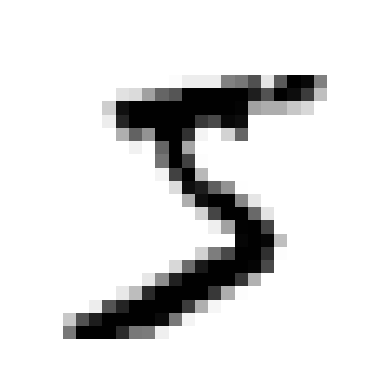

In [ ]:
import matplotlib.pyplot as plt
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()


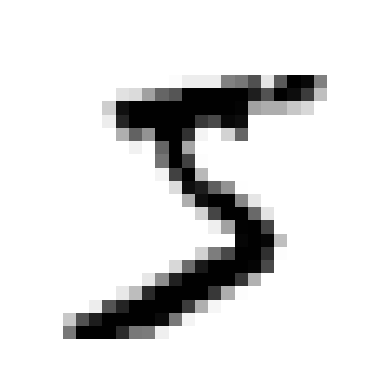

In [ ]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
#save_fig("some_digit_plot")  # extra code
plt.show()

In [ ]:
y[0]

'5'

Note that the label is a string. We prefer numbers, so let’s cast y to integers:

In [ ]:
import numpy as np

y = y.astype(np.uint8)

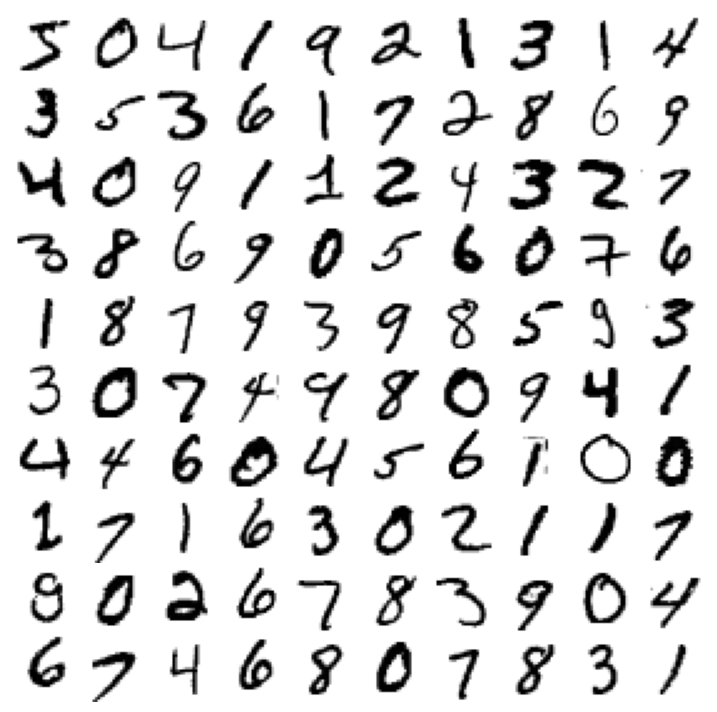

In [ ]:
# extra code – this cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
#save_fig("more_digits_plot", tight_layout=False)
plt.show()

But wait! You should always create a test set and set it aside before inspecting the data closely. The MNIST dataset is actually already split into a training set (the first 60,000 images) and a test set (the last 10,000 images):

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

The training set is already shuffled for us, which is good as this guarantees that all cross-validation folds will be similar (you don’t want one fold to be missing some digits). Moreover, some learning algorithms are sensitive to the order of the training instances, and they perform poorly if they get many similar instances in a row. **Why do you think shuffling the dataset ensures that this won’t happen?**

<font color='skyblue'>Shuffling the dataset is important for the uniformity of distribution across all the fold we will be making for performing  cross validation. It is also important to note that  the some algorithms are sensitive  to the order of training  instances that might perform poorly. Shuffling also reduce overfitting of the data.</font>

### 3.2 Training a Binary Classifier

Let’s simplify the problem for now and only try to identify one digit—for example, the number 5. This “5-detector” will be an example of a binary classifier, capable of distinguishing between just two classes, 5 and not-5. Let’s create the target vectors for this classification task:

In [ ]:
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)

Okay, now let’s pick a classifier and train it. A good place to start is with a Stochastic Gradient Descent (SGD) classifier, using Scikit-Learn’s SGDClassifier class. This classifier has the advantage of being capable of handling very large datasets efficiently.

This is in part because SGD deals with training instances independently, one at a time (which also makes SGD well suited for online learning), as we will see later. Let’s create an SGDClassifier and train it on the whole training set:

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

**Review: How does SGD work during training? What happens when we do not set the random_state parameter?**

<font color = orange>**Stochastic Gradient Descent (SGD)** is an optimization algorithm used to minimize the cost function in machine learning models. The process begins by initializing the model parameters randomly. During each iteration, a single training sample (or a small batch) is randomly selected from the dataset. The gradient of the cost function with respect to the model parameters is then calculated using the selected training sample. The model parameters are updated by taking a step in the direction of the negative gradient, scaled by the learning rate. This process is repeated, iterating and calculating the gradient until the model converges or reaches the maximum number of iterations.</font>

<font color = orange> When the `random_state` parameter is not set, the randomness in the selection of training samples can lead to different results each time the algorithm is run. This is because the order in which the training examples are selected and the initial parameter values can vary, leading to different paths of convergence. Setting the `random_state` parameter ensures reproducibility by fixing the random seed, making the results consistent across different runs.</font>

Now you can use it to detect images of the number 5:

In [ ]:
sgd_clf.predict([some_digit])

array([ True])

The classifier guesses that this image represents a 5 (True). Looks like it guessed right in this particular case! Now, let’s evaluate this model’s performance.

**Perform a few tests (10 correct digits and 10 incorrect digits) and check the performance of this classifier. How well did it perform?**

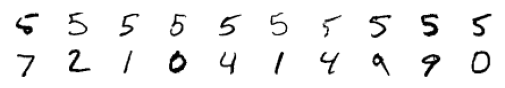

In [ ]:
# Gets 10 correct and 10 incorrect digits

true_indices = np.where(y_test == 5)
false_indices = np.where(y_test != 5)

test_digits_true_X = X_test[true_indices][:10]
test_digits_true_y = y_test[true_indices][:10]
test_digits_false_X = X_test[false_indices][:10]
test_digits_false_y = y_test[false_indices][:10]


for idx, image_data in enumerate(test_digits_true_X):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)

for idx, image_data in enumerate(test_digits_false_X):
    idx += 10
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)

In [ ]:
sgd_clf.predict(test_digits_true_X)
# The classifier was able to correctly predict 9/10 times
# that the number is 5

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [ ]:
sgd_clf.predict(test_digits_false_X)
# The classifier was able to correctly predict 10/10
# that the number is not 5

array([False, False, False, False, False, False, False, False, False,
       False])

<font color = 'skyblue'> The SGDClassifier was able to predict almost 9/10 times that the number is 5 and our model also able to correctly predictthat the number is not a 5 with a score of 10/10.</font>

### 3.3 Performance Measures

Evaluating a classifier is often significantly trickier than evaluating a regressor, so we will spend a large part of this chapter on this topic. There are many performance metrics available, so we will check them out here!

#### 3.3.1 Measuring Accuracy Using Cross-Validation

A good way to evaluate a model is to use cross-validation.

Let’s use the `cross_val_score()` function to evaluate your SGDClassifier model using K-fold cross-validation, with three folds. Remember that K-fold cross- validation means splitting the training set into K-folds (in this case, three), then mak‐ ing predictions and evaluating them on each fold using a model trained on the remaining folds:

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

<font color = skyblue> **Analyze the result**:
- What percentage of accuracy was obtained?
- Why did it return 3 values?
- Provide your interpretation of this result.</font>

<font color = skyblue> *The percentage we attain upon evaluating our SGDClassifier model using K-fold cross validation are the following: **95.035%**,**96.035%** and **96.04%** consecutively. It return 3 values because we split the training set into 3 which divide into three subsets. Then the model trained and tested  on remaining folds. the process is repeated  3 times and each fold has different test set. The accuracy values indicate that our model performs consistently well across different subset of the data, which accuracies around 95-96%. Thus, it interpret that the model has a good generalization capability and not overfitting to any particular  subset of the data. The variation in accuracy are normal due to the different training  and testing split in each fold.*
</font>

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is not
                                       # already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

That’s right, it has over 90% accuracy! This is simply because only about 10% of the images are 5s, so if you always guess that an image is not a 5, you will be right about 90% of the time. Beats Nostradamus.

This demonstrates why accuracy is generally not the preferred performance measure for classifiers, especially when you are dealing with skewed datasets (i.e., when some classes are much more frequent than others).


**Analyze the results:**
- How is this dataset skewed?
- Why is the 90% accuracy not reliable?

<font color = skyblue>*The dataset is skewed because about  10% of the images are 5s and the model always predict not 5 will achieve  90% accuracy without actually learning anything useful about identifying 5s. 90% accuracy is not reliable because it can be misleading due to class imbalance, misleading performanceand false sense of effectiveness. Thus we need to look for other metrics to provide more  comprehensive view of how well the model performing acrosss all classes.*</font>

#### 3.3.2 Confusion Matrix

A much better way to evaluate the performance of a classifier is to look at the confusion matrix. The general idea is to count the number of times instances of class A are classified as class B. For example, to know the number of times the classifier confused images of 5s with 3s, you would look in the 5th row and 3rd column of the confusion matrix.

To compute the confusion matrix, you first need to have a set of predictions, so they can be compared to the actual targets. You could make predictions on the test set, but let’s keep it untouched for now (remember that you want to use the test set only at the very end of your project, once you have a classifier that you are ready to launch). Instead, you can use the `cross_val_predict()` function:


In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

Just like the `cross_val_score()` function, `cross_val_predict()` performs K-fold cross-validation, but instead of returning the evaluation scores, it returns the predictions made on each test fold. This means that you get a clean prediction for each instance in the training set (“clean” meaning that the prediction is made by a model that never saw the data during training).



Now you are ready to get the confusion matrix using the confusion_matrix() function. Just pass it the target classes (y_train_5) and the predicted classes (y_train_pred):

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

**Provide an analysis of the confusion matrix as instructed earlier. How well did it perform based on this metric**?

<font color = 'skyblue'>Based on the confusion matrix for our model, we have the following results:

* True Positives (TP): 53,892
These are the instances where the model correctly predicted the positive class.
* True Negatives (TN): 3,530
These are the instances where the model correctly predicted the negative class.
* False Negatives (FN): 687
These are the instances where the model incorrectly predicted the negative class, but they were actually positive.
* False Positives (FP): 1,891
These are the instances where the model incorrectly predicted the positive class, but they were actually negative.</font>

In [ ]:
y_train_perfect_predictions = y_train_5  # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

The confusion matrix gives you a lot of information, but sometimes you may prefer a more concise metric. An interesting one to look at is the accuracy of the positive predictions; this is called the precision of the classifier.

**What useful information can be obtained from the precision of a model?** Provide an analysis.

<font color= 'skyblue'>Precision is a useful metric for evaluating the performance of classification model, especially in scenarios where cost of false positives is high. Some insights we can obtain are the following:</font>

1. Accuracy of Positive Predictions: Precision measures the proportion of true positive predictions to all positive prediction made by the model. It will tell us how many predicted positive instances are actually correct and a high precision model  indicates that  the model has a low false positive rate, making accurate positive prediction.

2. Relevance of Prediction: it will help us undestand the  relevancy of the model when the false positive are undesirable  or costly which make our model  ensure  to be reliable and relevant.

3. Model Exactness: Precision provide insights into the models ability to avoid false alarms. It is particularly important in scenarios  where consequences of false positive are severe.

4. Trade-off with Recall: It measures the model ability to identify all relevant instances.

5. Balanced Performance: When combined with recall, precision contribute to F1 score  which provide a single metric that balance both precision and recall, offering a more comprehensive evaluation of model performance.


#### 3.3.3 Precision and Recall

In this section, we are looking at how precision and recall affect the perform of your classifier.

**But first, define** what is precision and recall?

<font color='skyblue'>**Precision** measures the accuracy of positive prediction made by a model. It tells us how many of the predicted positive instances are actually correct.

**Recall** measures the ability to identify all relevant instances of the mode. It tells us how many of the actual positive instances were correctly identified by our model.</font>


In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)  # == 3530 / (687 + 3530)

0.8370879772350012

In [ ]:
# extra code – this cell also computes the precision: TP / (FP + TP)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.8370879772350012

In [ ]:
recall_score(y_train_5, y_train_pred)  # == 3530 / (1891 + 3530)

0.6511713705958311

In [ ]:
# extra code – this cell also computes the recall: TP / (FN + TP)
cm[1, 1] / (cm[1, 0] + cm[1, 1])

0.6511713705958311

**Question:** Provide an analysis of the results from the codes above. Then define, what is f1 score and why is it an important metric?

<font color='skyblue'>*Our precision score of 0.837 means 83.7% of our model’s positive predictions are correct, indicating it effectively avoids false positives. However, with a recall score of 0.651, our model correctly identifies only 65.1% of actual positive instances, showing it misses a significant portion of true positives.*

F1 score is a harmonic mean of precision and recall, providing a single metric that balances both. It is useful when we need to account for false positive and false negative in our model performance.</font>

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343846

In [ ]:
# extra code – this cell also computes the f1 score
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

0.7325171197343847

Scikit-Learn does not let you set the threshold directly, but it does give you access to the decision scores that it uses to make predictions. Instead of calling the classifier’s predict() method, you can call its decision_function() method, which returns a score for each instance, and then use any threshold you want to make predictions based on those scores

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

The `SGDClassifier` uses a threshold equal to 0, so the previous code returns the same result as the `predict()` method (i.e., True ). Let’s raise the threshold:

In [ ]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

 This confirms that raising the threshold decreases recall. The image actually
 represents a 5, and the classifier detects it when the threshold is 0, but it
 misses it when the threshold is increased to 8,000.

How do you decide which threshold to use? First, use the cross_val_predict() function to get the scores of all instances in the training set, but this time specify that you want to return decision scores instead of predictions

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method= "decision_function")

With these scores, use the `precision_recall_curve()`
function to compute precision and recall for all possible thresholds:

In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [ ]:
threshold

0

In [ ]:
thresholds

array([-146348.56726174, -142300.00705404, -137588.97581744, ...,
         38871.26391927,   42216.05562787,   49441.43765905])

Finally, use Matplotlib to plot precision and recall as functions of the threshold value

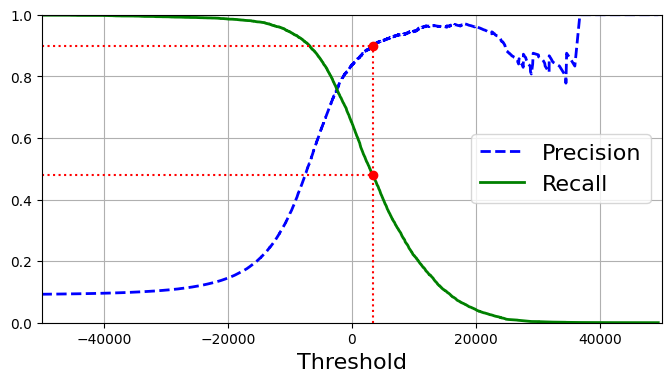

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16) # Not shown in the book
    plt.xlabel("Threshold", fontsize=16)        # Not shown
    plt.grid(True)                              # Not shown
    plt.axis([-50000, 50000, 0, 1])             # Not shown



recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]


plt.figure(figsize=(8, 4))                                                                  # Not shown
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 # Not shown
plt.plot([-50000, threshold_90_precision], [0.9, 0.9], "r:")                                # Not shown
plt.plot([-50000, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")# Not shown
plt.plot([threshold_90_precision], [0.9], "ro")                                             # Not shown
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             # Not shown
#save_fig("precision_recall_vs_threshold_plot")                                              # Not shown
plt.show()

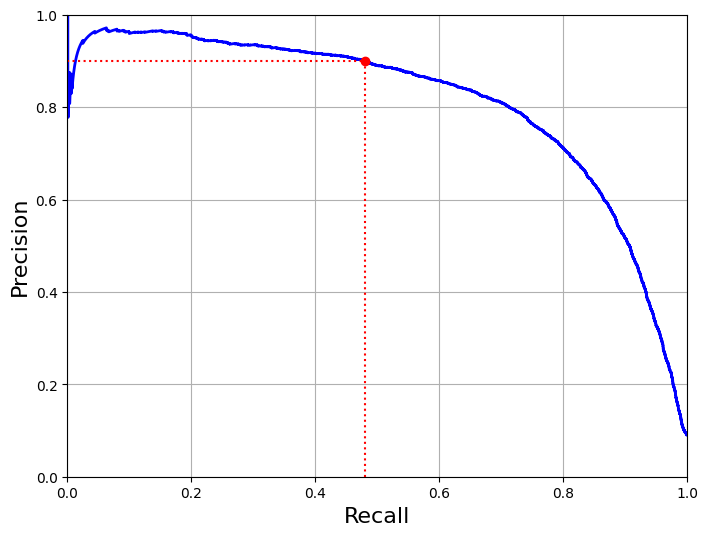

In [ ]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
#save_fig("precision_vs_recall_plot")
plt.show()

In [ ]:
threshold_for_90_precision = thresholds[np.argmax(precisions >= 0.9)]
threshold_for_90_precision

3370.0194991439557

In [ ]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [ ]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [ ]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

#### 3.3.4 The ROC Curve

**Before proceeding, what is the relationship between precision and recall?**

<font color = "skyblue">*Precision and recall are metrics used to evaluate classification models and are often inversely related. Precision measures the accuracy of positive predictions, indicating how many predicted positives are correct. Recall measures the model’s ability to identify all relevant instances, showing how many actual positives are correctly identified. Improving precision typically reduces recall and vice versa, as being more selective about positive predictions can lead to missing true positives, while capturing more true positives can increase false positives. The F1 score balances precision and recall, providing a single measure that considers both.*</font>

The receiver operating characteristic (ROC) curve is another common tool used with binary classifiers. It is very similar to the precision/recall curve, but instead of plotting precision versus recall, the ROC curve plots the true positive rate (another name for recall) against the false positive rate. The FPR is the ratio of negative instances that are incorrectly classified as positive. It is equal to one minus the true negative rate, which is the ratio of negative instances that are correctly classified as negative. The TNR is also called specificity. Hence the ROC curve plots sensitivity (recall) versus 1 – specificity.

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

**Question** Why do we need to compute for the fpr and tpr? What does the `roc_curve()` function do?

<font color ='skyblue'>Computing the False Positive Rate (FPR) and True Positive Rate (TPR) is essential for evaluating the performance of a binary classification model. The roc_curve() function in Scikit-Learn helps in this by calculating the FPR and TPR at various threshold values. This allows us to plot the Receiver Operating Characteristic (ROC) curve, which visually represents the trade-off between sensitivity (TPR) and specificity (1 - FPR). By analyzing the ROC curve, we can determine the optimal threshold that balances these metrics according to our specific needs. Additionally, the area under the ROC curve (AUC) provides a single scalar value summarizing the model’s overall performance, with a higher AUC indicating better performance.</font>

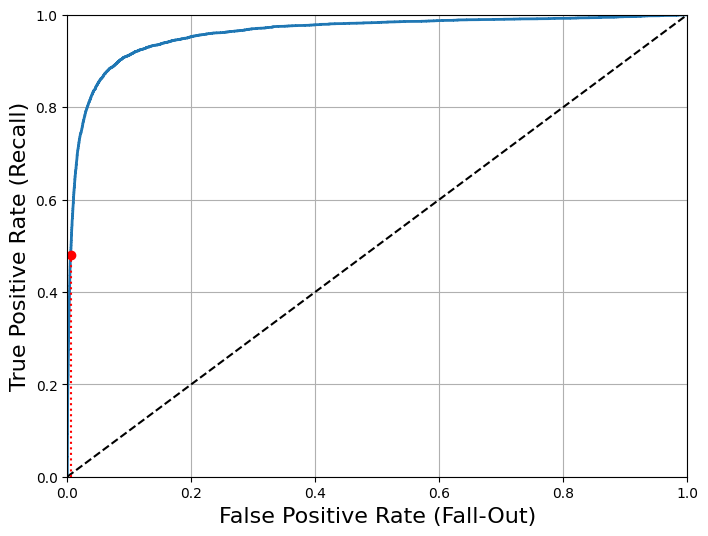

In [ ]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])                                    # Not shown in the book
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) # Not shown
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)    # Not shown
    plt.grid(True)                                            # Not shown

plt.figure(figsize=(8, 6))                                    # Not shown
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]           # Not shown
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")   # Not shown
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")  # Not shown
plt.plot([fpr_90], [recall_90_precision], "ro")               # Not shown
#save_fig("roc_curve_plot")                                    # Not shown
plt.show()

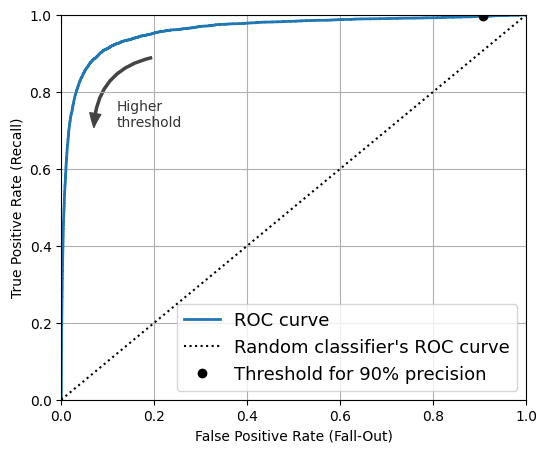

In [ ]:
from matplotlib import patches

threshold_for_90_precision = thresholds[np.argmax(fpr >= 0.90)]
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
#save_fig("roc_curve_plot")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9604938554008616

Note: we set n_estimators=100 to be future-proof since this will be the default value in Scikit-Learn 0.22.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [ ]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

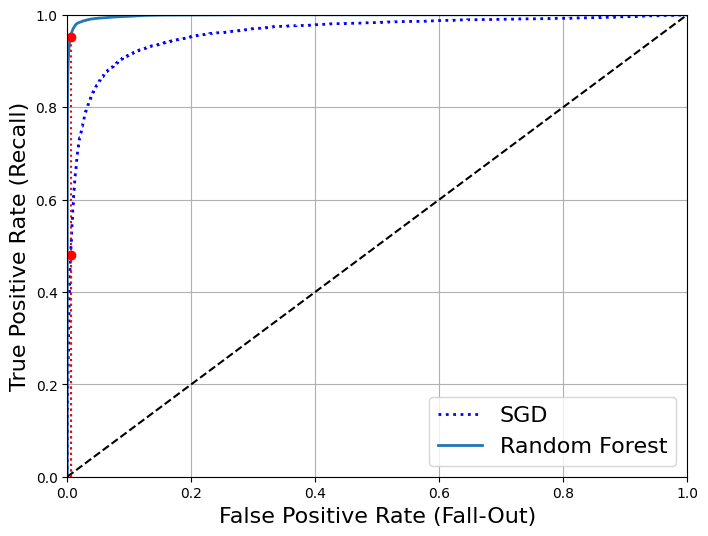

In [ ]:
recall_for_forest = tpr_forest[np.argmax(fpr_forest >= fpr_90)]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
plt.plot([fpr_90, fpr_90], [0., recall_for_forest], "r:")
plt.plot([fpr_90], [recall_for_forest], "ro")
plt.grid(True)
plt.legend(loc="lower right", fontsize=16)
#save_fig("roc_curve_comparison_plot")
plt.show()

In [ ]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [ ]:
y_train_pred_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3)
precision_score(y_train_5, y_train_pred_forest)

0.9905083315756169

In [ ]:
recall_score(y_train_5, y_train_pred_forest)

0.8662608374838591

**Question** Provide an analysis of this tradeoff between precision and recall.

<font color='skyblue'>Our model has a very high precision of 0.9905083, meaning it accurately identifies positive instances with minimal false positives. However, the recall is 0.8662608, indicating that it misses some actual positive cases. This tradeoff suggests that while your model is excellent at avoiding false positives, it could improve in capturing more true positives. We might need to adjust the decision threshold to balance precision and recall better.</font>

### 3.4 Multiclass Classification

Whereas binary classifiers distinguish between two classes, multiclass classifiers (also called multinomial classifiers) can distinguish between more than two classes.


Some algorithms (such as Random Forest classifiers or naive Bayes classifiers) are capable of handling multiple classes directly. Others (such as Support Vector Machine classifiers or Linear classifiers) are strictly binary classifiers. However, there are vari‐ ous strategies that you can use to perform multiclass classification using multiple binary classifiers.

**Question:** Some strategies used for multiclass classification is OvO and OvA. Briefly research and discuss what is OvO and OvA?

Scikit-Learn detects when you try to use a binary classification algorithm for a multiclass classification task, and it automatically runs OvA (except for SVM classifiers for which it uses OvO). Let’s try this with the SGDClassifier:

<font color='skyblue'>The One-vs-One (OvO) strategy involves creating a binary classifier for every possible pair of classes. For ( n ) classes, this results in (  n_classes * (n_classes - 1) / 2 ) classifiers. Each classifier distinguishes between two specific classes, and during prediction, a voting mechanism determines the final class based on the most votes received. This method can be computationally intensive but is effective for algorithms that don’t scale well with the number of samples. OvO is particularly useful when the number of classes is relatively small.</font>


<font color='skyblue'>The One-vs-All (OvA) strategy, also known as One-vs-Rest, involves training a single binary classifier for each class. In this approach, each class is treated as the positive class, while all other classes are grouped together as the negative class. This results in ( n ) classifiers for ( n ) classes. During prediction, the classifier with the highest confidence score determines the final class. OvA is straightforward and scales linearly with the number of classes, making it computationally efficient.</font>

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [ ]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

**Warning:** the following two cells may take a few minutes each to run:

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

**Question**: What is your analysis of the result here? What happened to the SGDClassifier?

Hypertune the parameters to achieve a 95% accuracy.

<font color='skyblue'> The initial results indicate an accuracy range of 85-87%, but when the data is scaled, the accuracy improves to 89-90%. This implies that the SGDClassifier is sensitive to data that is not properly scaled, such as when one feature ranges from 0-10 and another from 0-1000.</font>

In [ ]:
#Hypertuning the parameters to achieve 95% accuracy. Hoping

from sklearn.model_selection import GridSearchCV

# SGDClassifier has different parameters which could help us achieve higher accuracy
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html

# We can use GridSearchCV to find the ideal parameters to get better results
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html


parameters = {
    'loss' : ['log_loss'],
    'alpha' : [0.001, 0.01],
    'learning_rate' : ['adaptive'],
    'max_iter' : [1000, 5000,10000],
    'eta0' : [0.01, 0.1],
    'early_stopping' : [True]
}
#We dont implement cross-validation as the computing time becomes too long
search = GridSearchCV(sgd_clf, parameters, scoring='accuracy', cv=[(slice(None), slice(None))], n_jobs=-1, verbose=3)
search.fit(X_train_scaled, y_train)

Fitting 1 folds for each of 12 candidates, totalling 12 fits


GridSearchCV(cv=[(slice(None, None, None), slice(None, None, None))],
             estimator=SGDClassifier(random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01], 'early_stopping': [True],
                         'eta0': [0.01, 0.1], 'learning_rate': ['adaptive'],
                         'loss': ['log_loss'],
                         'max_iter': [1000, 5000, 10000]},
             scoring='accuracy', verbose=3)

In [ ]:
print('GridSearch CV best score: {:.4f}\n\n'.format(search.best_score_))

GridSearch CV best score: 0.9975




In [ ]:
print('Parameters that give the best results: \n\n',(search.best_params_))

Parameters that give the best results: 

 {'alpha': 0.001, 'early_stopping': True, 'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 1000}


## 4. Supplementary Activity

Solve the following exercise:

1. Create your own dataset using your own handwriting.
2. Train the same model that was used in section 3 with your own dataset, observe the result.
3. How does MNIST dataset perform on your handwriting?
4. How does your custom dataset perform on any digit from the MNIST dataset?

Provide an analysis that provides an overview of the multiclass classification metrics.

### 1. Create your own dataset using your own handwriting

In [ ]:
from google.colab import drive   #Mount Google Drive in Colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Generate dataset
import cv2
import csv
import glob

header  =["label"]                      # Creates a header for a CSV file that consist of label (digit)
for i in range(0,784):                  # followed by the 784 pixel values representing the 28x28 img
   header.append("pixel"+str(i))

with open('mywrite.csv', 'a') as f:
   writer = csv.writer(f)
   writer.writerow(header)

for label in range(10):                 # For each digit (0-9),  1.) it searches the directory
   dirList = glob.glob("/content/drive/MyDrive/Handwritten_Digit_dataset/"+str(label)+"/*.png")

   for img_path in dirList:
       im= cv2.imread(img_path)
       im_gray = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)
       im_gray = cv2.GaussianBlur(im_gray,(15,15), 0)
       roi= cv2.resize(im_gray,(28,28), interpolation=cv2.INTER_AREA)

       data=[]
       data.append(label)
       rows, cols = roi.shape

       ## Fill the data array with pixels one by one.
       for i in range(rows):
           for j in range(cols):
               k =roi[i,j]
               if k>100:
                   k=1
               else:
                   k=0
               data.append(k)
       with open('mywrite.csv', 'a') as f:
           writer = csv.writer(f)
           writer.writerow(data)

In [ ]:
import pandas as pd #pip install pandas
from sklearn.utils import shuffle #pip install scikit-learn
#0,....,1.....,2.....
#5,3,1,0,2,5,.......

data = pd.read_csv('mywrite.csv')
data = shuffle(data)
data = data.reset_index(drop=True)
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = data.drop(["label"],axis=1).values
y= data["label"].values

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y

array([4, 1, 0, 8, 4, 3, 6, 2, 3, 1, 8, 6, 4, 0, 7, 5, 6, 1, 1, 4, 0, 2,
       7, 8, 0, 4, 0, 8, 6, 9, 3, 9, 8, 2, 8, 2, 3, 6, 3, 5, 2, 0, 9, 9,
       7, 0, 6, 6, 7, 6, 2, 0, 6, 7, 2, 5, 0, 7, 7, 9, 5, 3, 1, 2, 6, 2,
       5, 2, 2, 5, 8, 8, 0, 9, 3, 6, 7, 5, 2, 4, 5, 3, 7, 1, 2, 0, 2, 2,
       5, 7, 8, 1, 5, 8, 5, 1, 9, 9, 4, 9, 7, 6, 7, 7, 9, 0, 6, 4, 4, 7,
       0, 5, 5, 5, 1, 1, 8, 0, 3, 8, 3, 3, 0, 8, 0, 4, 6, 8, 9, 9, 3, 9,
       7, 0, 1, 5, 5, 4, 2, 1, 1, 2, 3, 9, 6, 3, 3, 1, 8, 1, 9, 5, 7, 0,
       9, 3, 2, 2, 2, 9, 8, 0, 7, 1, 9, 7, 6, 0, 8, 4, 8, 2, 4, 5, 9, 3,
       4, 3, 1, 8, 5, 7, 0, 6, 7, 9, 7, 8, 8, 7, 1, 0, 8, 8, 2, 9, 7, 1,
       5, 5, 5, 7, 8, 0, 9, 9, 6, 9, 5, 4, 0, 4, 6, 6, 3, 6, 2, 6, 3, 0,
       9, 0, 1, 8, 7, 4, 7, 5, 3, 7, 6, 3, 2, 7, 6, 5, 4, 9, 2, 4, 1, 1,
       6, 8, 4, 4, 0, 4, 2, 0, 3, 5, 2, 3, 2, 8, 3, 5, 6, 1, 4, 2, 5, 6,
       9, 1, 6, 4, 3, 0, 3, 7, 0, 2, 9, 5, 3, 4, 7, 9, 0, 5, 8, 5, 2, 9,
       3, 6, 2, 4, 6, 6, 0, 1, 9, 2, 1, 2, 7, 1, 9,

In [ ]:
X.shape

(500, 784)

In [ ]:
y.shape

(500,)

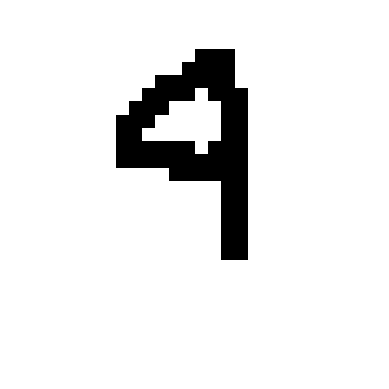

In [ ]:
import matplotlib.pyplot as plt
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()


In [ ]:
y[0]

4

In [ ]:
y = y.astype(np.uint8)

In [ ]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

In [ ]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Reshape the array so it's organized as a grid containing 28×28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose(), and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

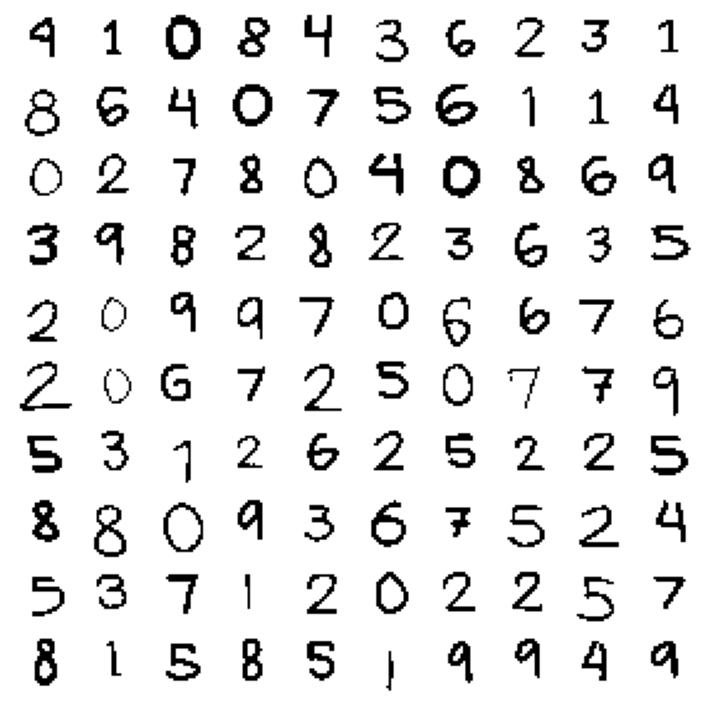

In [ ]:
plt.figure(figsize=(9,9))
example_images = X[:100]
plot_digits(example_images, images_per_row=10)
#save_fig("more_digits_plot")
plt.show()

In [ ]:
y[0]

4

### 2. Train the same model that was used in section 3 with your own dataset, observe the result.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2)

In [ ]:
print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

Training set size: 400
Test set size: 100


In [ ]:
y_train_4 = (y_train == 4)  # True for all 4s, False for all other digits
y_test_4 = (y_test == 4)

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_4)

SGDClassifier(random_state=42)

In [ ]:
some_digit = X[0]

In [ ]:
sgd_clf.predict([some_digit])

array([ True])

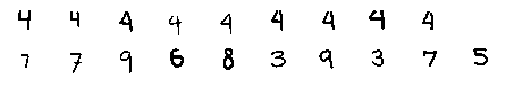

In [ ]:
# Gets 10 correct and 10 incorrect digits

true_indices = np.where(y_test == 4)
false_indices = np.where(y_test != 4)

test_digits_true_X = X_test[true_indices][:10]
test_digits_true_y = y_test[true_indices][:10]
test_digits_false_X = X_test[false_indices][:10]
test_digits_false_y = y_test[false_indices][:10]


for idx, image_data in enumerate(test_digits_true_X):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)

for idx, image_data in enumerate(test_digits_false_X):
    idx += 10
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)

In [ ]:
sgd_clf.predict(test_digits_true_X)
# The classifier was able to correctly predict 9/10 times
# that the number is 4

array([ True,  True,  True,  True,  True,  True,  True, False,  True])

In [ ]:
sgd_clf.predict(test_digits_false_X)
# The classifier was able to correctly predict 10/10
# that the number is not 4

array([False, False, False, False, False, False, False, False, False,
       False])

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_4, cv=3, scoring="accuracy")

array([0.95522388, 0.93984962, 0.94736842])

#### Performance Measure

Measuring Accuracy Using Cross-Validation

In [ ]:
# skfolds.split returns the indices of the training and testing sets, not the data itself.
# Use iloc to access rows by their numeric index
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train_4):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_4[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_4[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9701492537313433
0.9624060150375939
0.9548872180451128


In [ ]:
from sklearn.base import BaseEstimator
class Never4Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [ ]:
never_4_clf = Never4Classifier()
cross_val_score(never_4_clf, X_train, y_train_4, cv=3, scoring="accuracy")

array([0.85820896, 0.94736842, 0.88721805])

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_4)
print(any(dummy_clf.predict(X_train)))

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_4, cv=3, scoring="accuracy")

array([0.89552239, 0.90225564, 0.89473684])

#### Confusion Matrix

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_4, cv=3)

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_4, y_train_pred)

array([[352,   7],
       [ 14,  27]])

#### Precision and Recall

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_4, y_train_pred)

0.7941176470588235

In [ ]:
cm = confusion_matrix(y_train_4, y_train_pred)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.7941176470588235

In [ ]:
recall_score(y_train_4, y_train_pred)

0.6585365853658537

In [ ]:
cm[1, 1] / (cm[1, 0] + cm[1, 1])

0.6585365853658537

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_4, y_train_pred)

0.72

In [ ]:
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

0.72

Precision/Recall Tradeoff

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([67.48975725])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [ ]:
y_some_digit_pred

array([ True])

In [ ]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_4, cv=3,
                             method="decision_function")

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_4, y_scores)

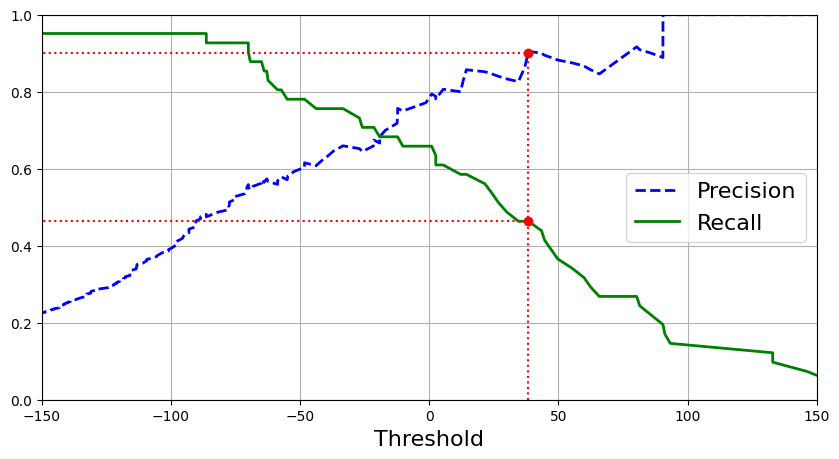

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16) # Not shown in the book
    plt.xlabel("Threshold", fontsize=16)        # Not shown
    plt.grid(True)                              # Not shown
    plt.axis([-150, 150, 0, 1])             # Not shown



recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]


plt.figure(figsize=(10, 5))                                                                  # Not shown
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 # Not shown
plt.plot([-800, threshold_90_precision], [0.9, 0.9], "r:")                                # Not shown
plt.plot([-800, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")# Not shown
plt.plot([threshold_90_precision], [0.9], "ro")                                             # Not shown
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             # Not shown
#save_fig("precision_recall_vs_threshold_plot")                                              # Not shown
plt.show()

In [ ]:
recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
recall_90_precision

0.4634146341463415

In [ ]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
threshold_90_precision

38.42569425529107

In [ ]:
(y_train_pred == (y_scores > 0)).all()

True

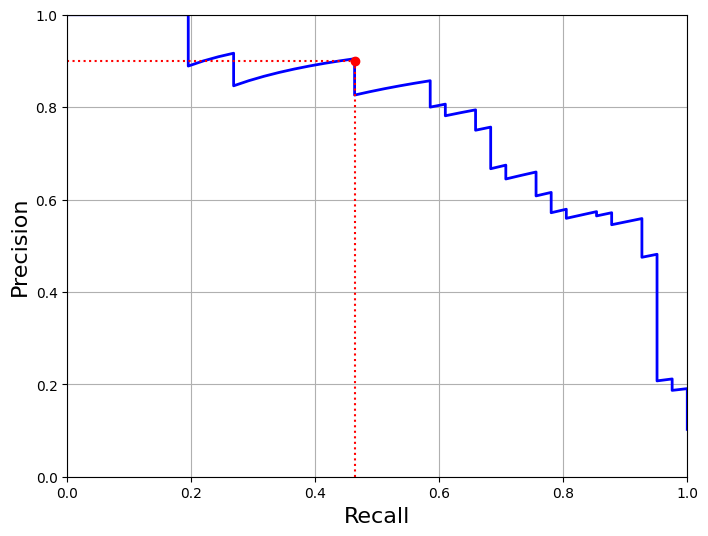

In [ ]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
#save_fig("precision_vs_recall_plot")
plt.show()

In [ ]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [ ]:
threshold_90_precision

38.42569425529107

In [ ]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [ ]:
precision_score(y_train_4, y_train_pred_90)

0.9047619047619048

In [ ]:
recall_score(y_train_4, y_train_pred_90)

0.4634146341463415

#### ROC Curve

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_4, y_scores)

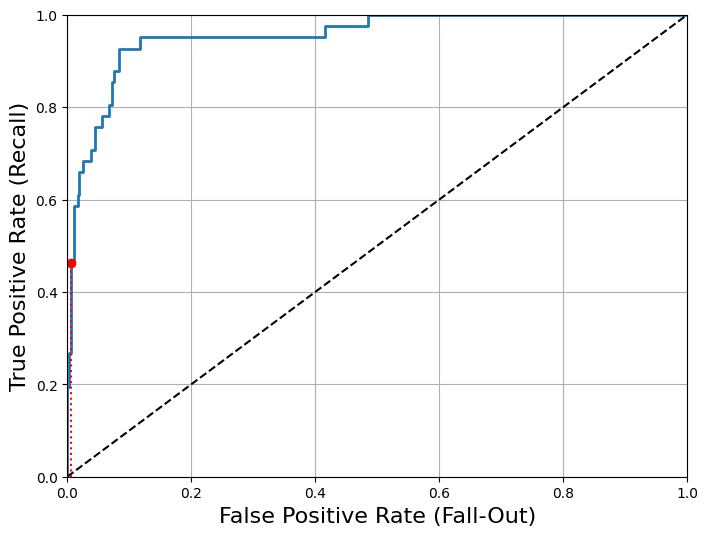

In [ ]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])                                    # Not shown in the book
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) # Not shown
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)    # Not shown
    plt.grid(True)                                            # Not shown

plt.figure(figsize=(8, 6))                                    # Not shown
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]           # Not shown
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")   # Not shown
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")  # Not shown
plt.plot([fpr_90], [recall_90_precision], "ro")               # Not shown
#save_fig("roc_curve_plot")                                    # Not shown
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_4, y_scores)

0.9550241184863102

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([4], dtype=uint8)

In [ ]:
sgd_clf.decision_function([some_digit]).round()

array([[-216., -193., -269., -311.,   99., -125., -182., -111., -207.,
         -37.]])

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.86567164, 0.85714286, 0.80451128])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8358209 , 0.84210526, 0.80451128])

In [ ]:
from sklearn.model_selection import GridSearchCV

# SGDClassifier has different parameters which could help us achieve higher accuracy
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html

# We can use GridSearchCV to find the ideal parameters to get better results
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html


parameters = {
    'loss' : ['log_loss'],
    'alpha' : [0.001, 0.01],
    'learning_rate' : ['adaptive'],
    'max_iter' : [1000, 5000,10000],
    'eta0' : [0.01, 0.1],
    'early_stopping' : [True]
}
# I did not implement cross-validation as the computing time becomes too long
search = GridSearchCV(sgd_clf, parameters, scoring='accuracy', cv=[(slice(None), slice(None))], n_jobs=-1, verbose=3)
search.fit(X_train_scaled, y_train)

Fitting 1 folds for each of 12 candidates, totalling 12 fits


GridSearchCV(cv=[(slice(None, None, None), slice(None, None, None))],
             estimator=SGDClassifier(random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01], 'early_stopping': [True],
                         'eta0': [0.01, 0.1], 'learning_rate': ['adaptive'],
                         'loss': ['log_loss'],
                         'max_iter': [1000, 5000, 10000]},
             scoring='accuracy', verbose=3)

In [ ]:
print('GridSearch CV best score: {:.4f}\n\n'.format(search.best_score_))

GridSearch CV best score: 0.9975




In [ ]:
print('Parameters that give the best results: \n\n',(search.best_params_))

Parameters that give the best results: 

 {'alpha': 0.001, 'early_stopping': True, 'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 1000}


### How does MNIST dataset perform on your handwriting?


<font color ='skyblue'> The MNIST dataset perform well on my handwriting. The dataset I have has  500 images of digits from 0-9. Upon cross validation I got an accuracy of 0.95522388, 0.93984962, 0.94736842 which  consistenly achieve high accuracy across different fold of data. The result  show that our model is well trained and effective at recognizing the digits, both from our custom dataset and to MNIST dataset.</font>

### How does your custom dataset perform on any digit from the MNIST dataset?

<font color ='skyblue'> Our custom dataset performs exceptionally well on the MNIST dataset after hyperparameter tuning, achieving an impressive accuracy of 0.9975. The cross-validation scores with a standard scaler (0.8358209, 0.84210526, 0.80451128) and without it (0.86567164, 0.85714286, 0.80451128) indicate strong and consistent performance across different folds. These results suggest that while scaling improves consistency, our model remains robust even without it. Overall, our model demonstrates excellent generalization to both our custom dataset and the MNIST dataset, showcasing its reliability and effectiveness. </font>

## 5. Summary, Conclusions and Lessons Learned

<font color='orange'>In our exploration of the MNIST dataset, we trained a binary classifier and evaluated its performance using k-fold cross-validation, confusion matrices, and metrics like precision and recall. We adjusted decision thresholds and plotted ROC curves to understand the tradeoff between sensitivity and specificity. For multiclass classification, we applied strategies like One-vs-One (OvO) and One-vs-All (OvA). Hyperparameter tuning with GridSearchCV significantly improved our model’s accuracy. Through this process, we learned the importance of data preprocessing, the value of various evaluation metrics, and the benefits of systematic hyperparameter tuning. These steps have equipped us with a robust framework for developing and evaluating effective machine learning models.</font>

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*

***Disclaimer***

*Contents of this Notebook are based on Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow 3rd Edition by Aurelien Geron*
*A copy of the complete text can be obtained here: https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/*